# Business Case 6 — Health-Based Segmentation

## Business Objective

Understand whether patient health characteristics are associated with appointment attendance patterns.

The objective is to help management:

- Identify differences in no-show patterns across health conditions
- Understand attendance patterns among patients with disabilities
- Support more targeted reminder and scheduling strategies
- Consider patient needs when planning appointment services

> This analysis identifies historical associations and should not be used to make clinical decisions or discriminate against patients based on health conditions.

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Load dataset
df_health = pd.read_csv(
    "../../data/Medical_appointment_data.csv"
)

# Remove exact duplicate rows
df_health = df_health.drop_duplicates().copy()

print("Dataset shape:", df_health.shape)

# Health-related columns
health_cols = [
    'gender',
    'age',
    'disability',
    'under_12_years_old',
    'over_60_years_old',
    'patient_needs_companion',
    'Hipertension',
    'Diabetes',
    'Alcoholism',
    'Handcap',
    'Scholarship',
    'SMS_received',
    'no_show'
]

print("\nHealth-related columns:")
print(health_cols)

print("\nMissing values:")
print(
    df_health[health_cols]
    .isnull()
    .sum()
)

Dataset shape: (109557, 26)

Health-related columns:
['gender', 'age', 'disability', 'under_12_years_old', 'over_60_years_old', 'patient_needs_companion', 'Hipertension', 'Diabetes', 'Alcoholism', 'Handcap', 'Scholarship', 'SMS_received', 'no_show']

Missing values:
gender                         0
age                        22929
disability                 16571
under_12_years_old             0
over_60_years_old              0
patient_needs_companion        0
Hipertension                   0
Diabetes                       0
Alcoholism                     0
Handcap                        0
Scholarship                    0
SMS_received                   0
no_show                        0
dtype: int64


In [4]:
# Convert no-show status into numeric values

df_health['no_show_numeric'] = (
    df_health['no_show']
    .map({'no': 0, 'yes': 1})
)

print("No-show distribution:")
print(
    df_health['no_show_numeric']
    .value_counts()
    .sort_index()
)

print("\nOverall no-show rate:")
print(
    round(df_health['no_show_numeric'].mean() * 100, 2),
    "%"
)

No-show distribution:
no_show_numeric
0    74726
1    34831
Name: count, dtype: int64

Overall no-show rate:
31.79 %


In [5]:
# Inspect unique values in health-related categorical/binary fields

health_category_cols = [
    'gender',
    'disability',
    'under_12_years_old',
    'over_60_years_old',
    'patient_needs_companion',
    'Hipertension',
    'Diabetes',
    'Alcoholism',
    'Handcap',
    'Scholarship',
    'SMS_received'
]

for col in health_category_cols:
    print(f"\n--- {col} ---")
    print(df_health[col].value_counts(dropna=False))


--- gender ---
gender
M    82236
F    27074
I      247
Name: count, dtype: int64

--- disability ---
disability
intellectual    62847
motor           29720
NaN             16571
                  419
Name: count, dtype: int64

--- under_12_years_old ---
under_12_years_old
0    60635
1    48922
Name: count, dtype: int64

--- over_60_years_old ---
over_60_years_old
0    101740
1      7817
Name: count, dtype: int64

--- patient_needs_companion ---
patient_needs_companion
1    56966
0    52591
Name: count, dtype: int64

--- Hipertension ---
Hipertension
0    103191
1      6366
Name: count, dtype: int64

--- Diabetes ---
Diabetes
0    106932
1      2625
Name: count, dtype: int64

--- Alcoholism ---
Alcoholism
0    107525
1      2032
Name: count, dtype: int64

--- Handcap ---
Handcap
0    108558
1       999
Name: count, dtype: int64

--- Scholarship ---
Scholarship
0    103518
1      6039
Name: count, dtype: int64

--- SMS_received ---
SMS_received
0    75392
1    34165
Name: count, dtype: 

In [7]:
# No-show rates by major health conditions

health_condition_cols = [
    'Hipertension',
    'Diabetes',
    'Alcoholism',
    'Handcap'
]

for col in health_condition_cols:
    analysis = (
        df_health.groupby(col, dropna=False)
        .agg(
            total_appointments=('no_show', 'count'),
            no_shows=('no_show_numeric', 'sum')
        )
        .reset_index()
    )

    analysis['no_show_rate_pct'] = (
        analysis['no_shows']
        / analysis['total_appointments']
        * 100
    )

    print(f"\n--- {col} ---")
    print(analysis.round(2).to_string(index=False))


--- Hipertension ---
 Hipertension  total_appointments  no_shows  no_show_rate_pct
            0              103191     33149             32.12
            1                6366      1682             26.42

--- Diabetes ---
 Diabetes  total_appointments  no_shows  no_show_rate_pct
        0              106932     34107             31.90
        1                2625       724             27.58

--- Alcoholism ---
 Alcoholism  total_appointments  no_shows  no_show_rate_pct
          0              107525     34257             31.86
          1                2032       574             28.25

--- Handcap ---
 Handcap  total_appointments  no_shows  no_show_rate_pct
       0              108558     34524             31.80
       1                 999       307             30.73


In [8]:
# No-show rates by disability and patient-support characteristics

group_cols = [
    'disability',
    'patient_needs_companion',
    'under_12_years_old',
    'over_60_years_old',
    'gender'
]

for col in group_cols:
    analysis = (
        df_health.groupby(col, dropna=False)
        .agg(
            total_appointments=('no_show', 'count'),
            no_shows=('no_show_numeric', 'sum')
        )
        .reset_index()
    )

    analysis['no_show_rate_pct'] = (
        analysis['no_shows']
        / analysis['total_appointments']
        * 100
    )

    print(f"\n--- {col} ---")
    print(
        analysis
        .round(2)
        .to_string(index=False)
    )


--- disability ---
  disability  total_appointments  no_shows  no_show_rate_pct
                             419       284             67.78
intellectual               62847     18219             28.99
       motor               29720      8642             29.08
         NaN               16571      7686             46.38

--- patient_needs_companion ---
 patient_needs_companion  total_appointments  no_shows  no_show_rate_pct
                       0               52591     18327             34.85
                       1               56966     16504             28.97

--- under_12_years_old ---
 under_12_years_old  total_appointments  no_shows  no_show_rate_pct
                  0               60635     20306             33.49
                  1               48922     14525             29.69

--- over_60_years_old ---
 over_60_years_old  total_appointments  no_shows  no_show_rate_pct
                 0              101740     33031             32.47
                 1            

In [9]:
# No-show rates by SMS reminder and scholarship status

support_cols = [
    'SMS_received',
    'Scholarship'
]

for col in support_cols:
    analysis = (
        df_health.groupby(col)
        .agg(
            total_appointments=('no_show', 'count'),
            no_shows=('no_show_numeric', 'sum')
        )
        .reset_index()
    )

    analysis['no_show_rate_pct'] = (
        analysis['no_shows']
        / analysis['total_appointments']
        * 100
    )

    print(f"\n--- {col} ---")
    print(
        analysis
        .round(2)
        .to_string(index=False)
    )


--- SMS_received ---
 SMS_received  total_appointments  no_shows  no_show_rate_pct
            0               75392     23946             31.76
            1               34165     10885             31.86

--- Scholarship ---
 Scholarship  total_appointments  no_shows  no_show_rate_pct
           0              103518     32913             31.79
           1                6039      1918             31.76


In [10]:
# Create a combined summary of major health conditions

condition_summary = []

for col in [
    'Hipertension',
    'Diabetes',
    'Alcoholism',
    'Handcap'
]:
    temp = (
        df_health.groupby(col)
        .agg(
            total_appointments=('no_show', 'count'),
            no_shows=('no_show_numeric', 'sum')
        )
        .reset_index()
    )

    temp['no_show_rate_pct'] = (
        temp['no_shows']
        / temp['total_appointments']
        * 100
    )

    temp['health_factor'] = col
    temp = temp.rename(columns={col: 'status'})

    condition_summary.append(temp)

health_summary = pd.concat(
    condition_summary,
    ignore_index=True
)

health_summary = health_summary[
    [
        'health_factor',
        'status',
        'total_appointments',
        'no_shows',
        'no_show_rate_pct'
    ]
]

print("Health Condition Summary:")
print(
    health_summary
    .round(2)
    .to_string(index=False)
)

Health Condition Summary:
health_factor  status  total_appointments  no_shows  no_show_rate_pct
 Hipertension       0              103191     33149             32.12
 Hipertension       1                6366      1682             26.42
     Diabetes       0              106932     34107             31.90
     Diabetes       1                2625       724             27.58
   Alcoholism       0              107525     34257             31.86
   Alcoholism       1                2032       574             28.25
      Handcap       0              108558     34524             31.80
      Handcap       1                 999       307             30.73


<Figure size 1000x600 with 0 Axes>

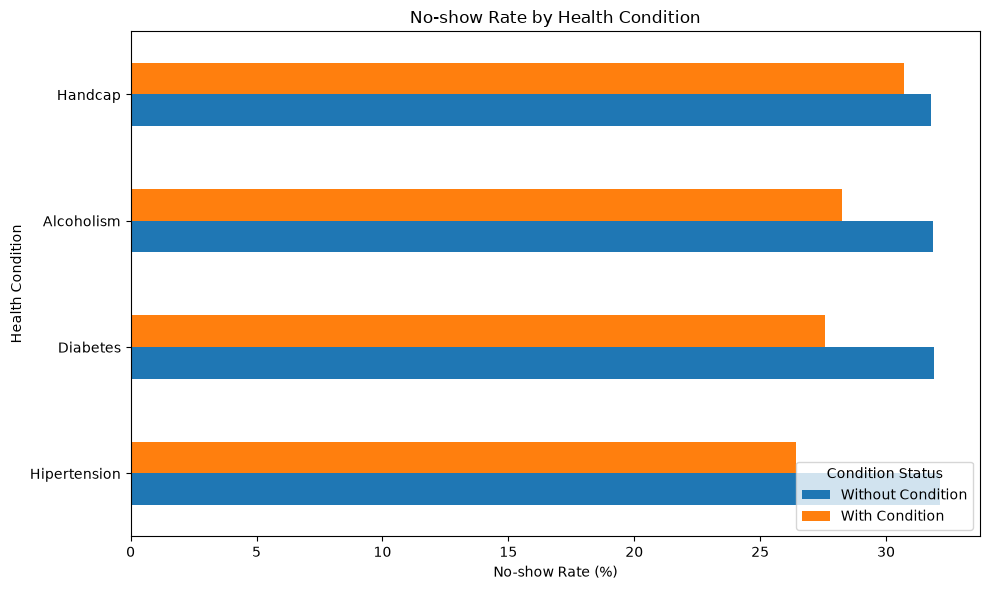

In [11]:
# Plot no-show rate by major health condition

plot_data = health_summary.pivot(
    index='health_factor',
    columns='status',
    values='no_show_rate_pct'
)

plot_data.columns = ['Without Condition', 'With Condition']

plot_data = plot_data.sort_values(
    'With Condition',
    ascending=True
)

plt.figure(figsize=(10, 6))

plot_data.plot(
    kind='barh',
    figsize=(10, 6)
)

plt.xlabel('No-show Rate (%)')
plt.ylabel('Health Condition')
plt.title('No-show Rate by Health Condition')
plt.legend(title='Condition Status')

plt.tight_layout()
plt.show()

In [12]:
from scipy.stats import chi2_contingency

# Chi-square tests for health conditions

for col in [
    'Hipertension',
    'Diabetes',
    'Alcoholism',
    'Handcap'
]:
    table = pd.crosstab(
        df_health[col],
        df_health['no_show_numeric']
    )

    chi2, p_value, dof, expected = chi2_contingency(table)

    print(f"\n--- {col} ---")
    print("Chi-square:", round(chi2, 4))
    print("p-value:", p_value)

    if p_value < 0.05:
        print("Result: Statistically significant association")
    else:
        print("Result: No statistically significant association")


--- Hipertension ---
Chi-square: 89.6482
p-value: 2.8450812625806542e-21
Result: Statistically significant association

--- Diabetes ---
Chi-square: 21.8006
p-value: 3.025118885832848e-06
Result: Statistically significant association

--- Alcoholism ---
Chi-square: 11.8296
p-value: 0.0005829764345568376
Result: Statistically significant association

--- Handcap ---
Chi-square: 0.476
p-value: 0.4902544721745945
Result: No statistically significant association


In [13]:
# Create a simple health-condition count

condition_cols = [
    'Hipertension',
    'Diabetes',
    'Alcoholism'
]

df_health['health_condition_count'] = (
    df_health[condition_cols].sum(axis=1)
)

condition_count_analysis = (
    df_health.groupby('health_condition_count')
    .agg(
        total_appointments=('no_show', 'count'),
        no_shows=('no_show_numeric', 'sum')
    )
    .reset_index()
)

condition_count_analysis['no_show_rate_pct'] = (
    condition_count_analysis['no_shows']
    / condition_count_analysis['total_appointments']
    * 100
)

print("No-show rate by number of health conditions:")
print(
    condition_count_analysis
    .round(2)
    .to_string(index=False)
)

No-show rate by number of health conditions:
 health_condition_count  total_appointments  no_shows  no_show_rate_pct
                      0               99818     32118             32.18
                      1                8511      2457             28.87
                      2                1172       245             20.90
                      3                  56        11             19.64


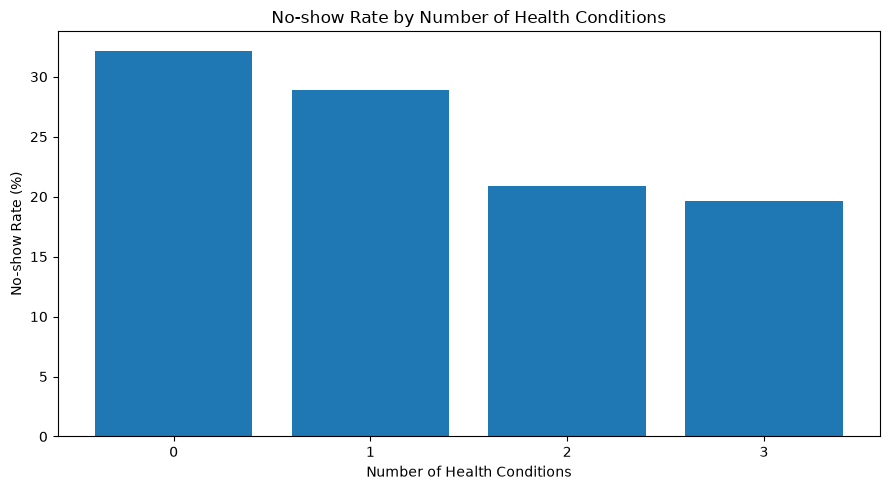

In [14]:
# Plot no-show rate by number of health conditions

plt.figure(figsize=(9, 5))

plt.bar(
    condition_count_analysis['health_condition_count'].astype(str),
    condition_count_analysis['no_show_rate_pct']
)

plt.xlabel('Number of Health Conditions')
plt.ylabel('No-show Rate (%)')
plt.title('No-show Rate by Number of Health Conditions')

plt.tight_layout()
plt.show()

In [15]:
# Compare no-show rates by health-condition count
# and whether the patient needs a companion

support_analysis = (
    df_health.groupby(
        ['health_condition_count', 'patient_needs_companion']
    )
    .agg(
        total_appointments=('no_show', 'count'),
        no_shows=('no_show_numeric', 'sum')
    )
    .reset_index()
)

support_analysis['no_show_rate_pct'] = (
    support_analysis['no_shows']
    / support_analysis['total_appointments']
    * 100
)

print("Health conditions and companion requirement:")
print(
    support_analysis
    .round(2)
    .to_string(index=False)
)

Health conditions and companion requirement:
 health_condition_count  patient_needs_companion  total_appointments  no_shows  no_show_rate_pct
                      0                        0               48855     17091             34.98
                      0                        1               50963     15027             29.49
                      1                        0                3551      1169             32.92
                      1                        1                4960      1288             25.97
                      2                        0                 182        64             35.16
                      2                        1                 990       181             18.28
                      3                        0                   3         3            100.00
                      3                        1                  53         8             15.09


In [16]:
# Final health-based segmentation summary

final_health_summary = condition_count_analysis.copy()

final_health_summary['segment'] = (
    final_health_summary['health_condition_count']
    .map({
        0: 'No recorded conditions',
        1: '1 recorded condition',
        2: '2 recorded conditions',
        3: '3 recorded conditions'
    })
)

final_health_summary = final_health_summary[
    [
        'segment',
        'health_condition_count',
        'total_appointments',
        'no_shows',
        'no_show_rate_pct'
    ]
]

print("Final Health-Based Segmentation Summary:")
print(
    final_health_summary
    .round(2)
    .to_string(index=False)
)

Final Health-Based Segmentation Summary:
               segment  health_condition_count  total_appointments  no_shows  no_show_rate_pct
No recorded conditions                       0               99818     32118             32.18
  1 recorded condition                       1                8511      2457             28.87
 2 recorded conditions                       2                1172       245             20.90
 3 recorded conditions                       3                  56        11             19.64


## Business Insight — Health-Based Segmentation

The analysis examined whether health-related characteristics are associated with appointment attendance patterns.

### Key Findings

- The overall no-show rate in the dataset is **31.79%**.
- Patients with **no recorded hypertension, diabetes, or alcoholism** had a no-show rate of **32.18%**.
- Patients with **1 recorded condition** had a no-show rate of **28.87%**.
- Patients with **2 recorded conditions** had a no-show rate of **20.90%**.
- Patients with **3 recorded conditions** had a no-show rate of **19.64%**, although this group contains only **56 appointments**.
- Chi-square testing found statistically significant associations between no-show status and:
  - **Hypertension:** p < 0.001
  - **Diabetes:** p < 0.001
  - **Alcoholism:** p < 0.001
- `Handcap` was not statistically significantly associated with no-show status in this analysis (p = 0.4903).
- Patients requiring a companion generally showed lower observed no-show rates within the health-condition groups.

### Operational Approach

Healthcare management could use these findings to support more context-aware appointment services:

- Consider patient support requirements when designing reminder and scheduling processes.
- Provide flexible communication and rescheduling options where additional support may be useful.
- Combine health-related characteristics with other operational factors such as appointment timing, specialty, and predicted no-show risk.
- Monitor attendance patterns regularly using updated data rather than relying only on historical patterns.

### Business Value

Health-based segmentation can help healthcare organizations understand differences in appointment attendance patterns and design more appropriate operational support strategies.

> **Important:** These findings represent statistical associations in historical appointment data. They do not establish that a health condition causes a patient to attend or miss an appointment and should not be used for clinical decisions or discriminatory treatment.

> The three-condition group contains only **56 appointments**, and the three-condition/no-companion subgroup contains only **3 appointments**. These small groups should therefore be interpreted cautiously.

> Health-related characteristics should be used responsibly and together with appropriate privacy, fairness, and healthcare governance requirements.